<a href="https://colab.research.google.com/github/harinathreddy-ai/Python-for-ai/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression
Import needed packages


*   NumPy
Matplotlib
Pandas
Scikit-learn



In [1]:
import sys
# Some libraries, like NumPy, are pre-installed in Colab and may need a restart of the runtime to be updated.
# If you encounter issues, try restarting the runtime (Runtime > Restart runtime).
!pip install pandas==2.2.2
!pip install numpy==1.26.4
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

# import libraries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Load data


In [3]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [4]:
df=pd.read_csv(url)
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


# Explore data

In [5]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [6]:
cdf=df[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB","CO2EMISSIONS"]]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


# Vizualize feratures

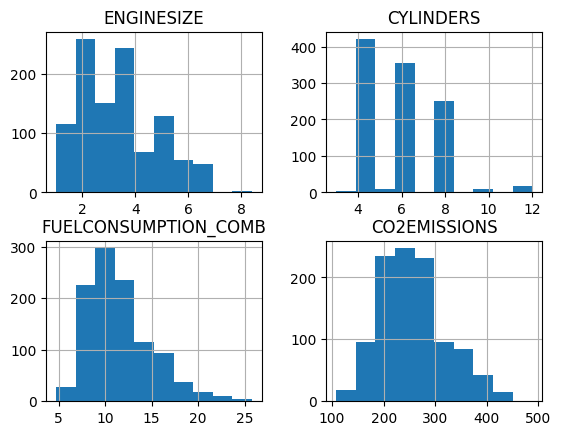

In [7]:
cdf.hist()
plt.show()

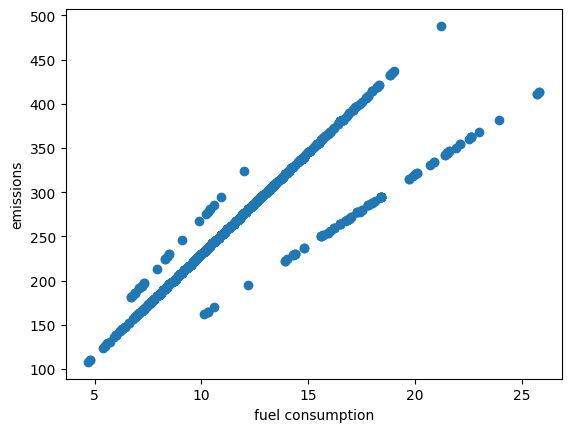

In [8]:
#fuel consumption vs c02 emissions
plt.scatter(cdf['FUELCONSUMPTION_COMB'],cdf['CO2EMISSIONS'])
plt.xlabel('fuel consumption')
plt.ylabel('emissions')
plt.show()

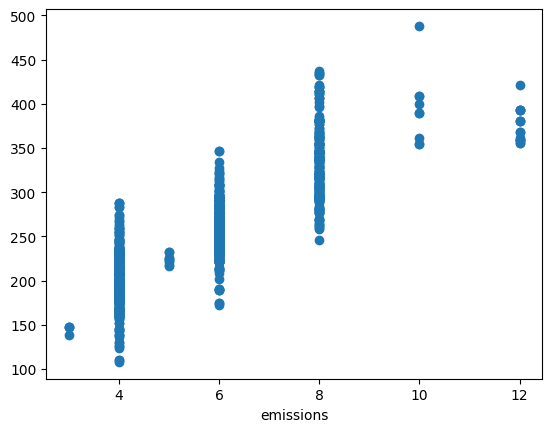

In [9]:
#cylinders vs c02 emissions
plt.scatter(cdf['CYLINDERS'],cdf['CO2EMISSIONS'])
plt.xlabel('cylinders')
plt.xlabel('emissions')
plt.show()


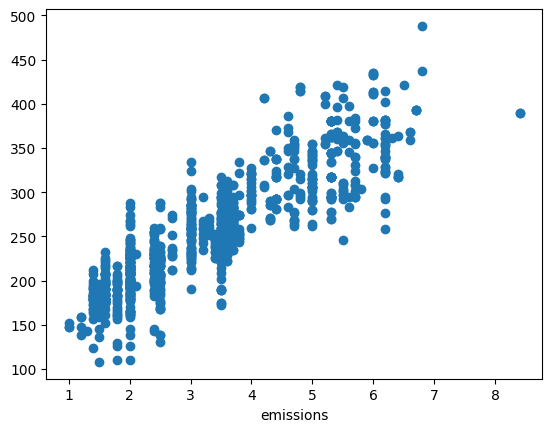

In [10]:
#engine size vs co2 emissions
plt.scatter(cdf['ENGINESIZE'],cdf['CO2EMISSIONS'])
plt.xlabel('engin size')
plt.xlabel('emissions')
plt.show()

# Extract input features from dataset

In [11]:
x=cdf.ENGINESIZE.to_numpy()
y=cdf.CO2EMISSIONS.to_numpy()

# Create train and test datasets

In [18]:
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)
X_train


array([1.4, 4.4, 3. , 3. , 5.3, 4.4, 3.7, 2. , 4. , 3.6, 4.2, 2.4, 6.5,
       5. , 5.7, 3.7, 6.2, 3.5, 3.6, 2.4, 3.6, 2. , 2. , 2.5, 1.4, 3.6,
       3.6, 3.6, 4. , 2. , 3.5, 5.6, 2.5, 4. , 3.5, 1.6, 2. , 3.5, 5.3,
       3.7, 2. , 6.6, 3.7, 5.6, 3.6, 6.2, 3. , 1.4, 4.4, 4.3, 5. , 3.7,
       2. , 3.6, 2.4, 5.3, 5.7, 5.5, 1.6, 3. , 3.5, 4. , 3. , 1.6, 2.4,
       3. , 3.6, 1.4, 2.4, 2. , 3. , 5.4, 2.4, 4.8, 2. , 3.5, 3.6, 1.8,
       2. , 4.6, 5.3, 2.4, 5.8, 5. , 1.4, 2. , 2.7, 1.8, 2.5, 4. , 6. ,
       3. , 3. , 2. , 1.2, 2.4, 3. , 4.6, 5. , 2. , 2. , 1.6, 2. , 5.3,
       6.2, 1.5, 2.5, 2. , 3.6, 5.4, 3.5, 3.6, 2. , 4.4, 3. , 1.4, 6.2,
       2. , 6. , 3.6, 3.6, 5.3, 2.4, 5.3, 5. , 5.3, 3.5, 2.7, 4.4, 2.5,
       1.8, 2.5, 5.7, 5.3, 2.4, 2. , 6.2, 1.6, 2. , 1.6, 3. , 2.5, 5.3,
       3.5, 5.3, 3.8, 4.8, 3.7, 6. , 2.5, 2.4, 1.6, 3.8, 6.2, 2.5, 1.6,
       2. , 2.5, 1.8, 3.5, 6.6, 3.7, 1.5, 2.4, 2. , 3.6, 4.8, 3.6, 3. ,
       1.5, 2.7, 1.6, 2.4, 5. , 3.7, 1.2, 2.5, 2.4, 2.4, 3.5, 2.

# Build a simple linear regression model

In [16]:
model=linear_model.LinearRegression()
model.fit(X_train.reshape(-1,1),Y_train)


LinearRegression()

# Visualize model outputs

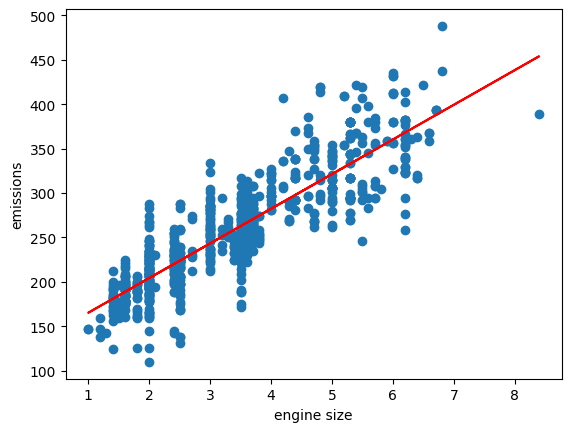

In [17]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,model.coef_ * X_train+ model.intercept_,'-r')
plt.xlabel("engine size")
plt.ylabel("emissions")
plt.show()

# Model evalustion

In [19]:
y_pre=model.predict(X_test.reshape(-1,1))
print("mean squared error: %.2f" % mean_squared_error(Y_test,y_pre))
print("mean absolute error: %.2f" % mean_absolute_error(Y_test,y_pre))
print("r2 score: %.2f" % r2_score(Y_test,y_pre))

mean squared error: 985.94
mean absolute error: 24.10
r2 score: 0.76
